# D1 — Streaming Learner & AutoML Note
**Module:** CSAI415 — *PDF-Papers AI Agent: Hybrid Retrieval + GraphRAG with Online Learning and AutoML*

**Team:** Khalifa (AutoML) · Meshal (Online learning) · Mahmoud (Retriever) · Ahmed (Corpus & gold) · Essam (Report & integration)

**This notebook bundles the full D1 pipeline:**
1. Build a 150-paper synthetic arXiv-style corpus (offline-friendly stand-in for the eventual PDF ingestion in D2).
2. Build a hybrid retriever: **BM25 + (TF-IDF [+ TruncatedSVD])**, tunable.
3. Build a 78-query gold set with three query types (broad, targeted, title).
4. Compute **baseline** Recall@5 / NDCG@5 / p95 latency.
5. Run **Optuna AutoML** (Track A): tune k, metric, SVD dim, L2-norm, hybrid λ.
6. Add a **River** incremental classifier (logistic regression over λ-buckets, with ε-greedy and **ADWIN** drift handling), evaluate prequentially.
7. Save the **run card** YAML.

All artefacts (`results/*.json`, `results/*.png`, `run_card.yaml`) are written next to this notebook.


## 0 — Setup


In [1]:
import json, sys, importlib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path('.').resolve()
sys.path.insert(0, str(ROOT / 'src'))            # so we can import the src/ modules
DATA = ROOT / 'data'; RESULTS = ROOT / 'results'
DATA.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)

# Show package versions used in this run (also dumped to run_card.yaml later)
for mod in ['numpy', 'pandas', 'sklearn', 'rank_bm25', 'optuna', 'river']:
    try:
        m = importlib.import_module(mod)
        print(f'{mod:12s} {getattr(m, "__version__", "ok")}')
    except Exception as e:
        print(f'{mod:12s} {e}')


numpy        2.2.6
pandas       2.3.3


sklearn      1.7.2
rank_bm25    ok
optuna       4.8.0
river        0.22.0


/sessions/magical-fervent-meitner/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Build the corpus (150 papers across 6 topics)
Six topic clusters: `transformers`, `rag`, `online_learning`, `vision`, `rl_agents`, `automl`. Each paper has a title, abstract, authors, venue, year, topic — schema mirrors the brief's required metadata.


In [2]:
from build_corpus import build_corpus
corpus = build_corpus(target_size=150)           # procedural corpus generation
out = DATA / 'corpus.parquet'
corpus.to_parquet(out, index=False)              # persist for downstream cells
(DATA / 'corpus_hash.txt').write_text(corpus.attrs['corpus_hash'])
print(f'Wrote {out}  hash={corpus.attrs["corpus_hash"]}')
corpus.head()                                    # quick visual check


Wrote /sessions/magical-fervent-meitner/mnt/special topic in ai/D1/data/corpus.parquet  hash=5faacf8028b6ce00


,paper_id,title,abstract,authors,venue,year,topic,text
0,P0000,Sparse Transformers for Language Modeling,We study sparse transformers for language mode...,"Aiko Ivanov, Aiko Yamada",ACL,2022,transformers,Sparse Transformers for Language Modeling. We ...
1,P0001,FlashAttention for Document Understanding,We study flashattention for document understan...,"Sasha Khoury, Aiko Kim, Yuri Nguyen, Aiko Okafor",KDD,2023,transformers,FlashAttention for Document Understanding. We ...
2,P0002,Mixture-of-Experts with Memory Compression,We study mixture-of-experts with memory compre...,"Nadia Costa, Tariq Levin, Lucia Hassan, Diego ...",EMNLP,2024,transformers,Mixture-of-Experts with Memory Compression. We...
3,P0003,Pre-Norm in Low-Resource Settings,We study pre-norm in low-resource settings. Th...,"Diego Smith, Owen Smith, Lucia Levin, Aiko Tan...",AAAI,2021,transformers,Pre-Norm in Low-Resource Settings. We study pr...
4,P0004,Mixture-of-Experts via Sliding Windows,We study mixture-of-experts via sliding window...,"Aiko Patel, Kenji Levin, Owen Ricci, Kenji Okafor",AAAI,2020,transformers,Mixture-of-Experts via Sliding Windows. We stu...


## 2 — Hybrid BM25 + dense retriever
*Lexical:* BM25Okapi (rank_bm25). &nbsp;*Dense:* TF-IDF → optional TruncatedSVD → optional L2-norm.
Final score = `λ * minmax(BM25) + (1-λ) * minmax(dense)`. The dense module will be swapped to `sentence-transformers/bge-small-en` in D2 once full ingestion is available — the `HybridRetriever` interface stays the same.


In [3]:
from retriever import HybridConfig, HybridRetriever
cfg = HybridConfig(k=10, metric='cosine', svd_dim=128, l2_normalize=True, hybrid_lambda=0.5)
retriever = HybridRetriever(cfg).fit(corpus)     # fits BM25 + TF-IDF + (optional) SVD
# Quick three-query smoke test to verify topic alignment + latency
demo, lat = retriever.search_many(
    ['graphrag subgraph expansion', 'concept drift detection', 'optuna hyperparameter search'], top_k=3)
for q, hits in zip(['graphrag', 'drift', 'optuna'], demo):
    print(f'{q:10s} →', [pid for pid,_ in hits])
print(f'mean latency {np.mean(lat):.2f}ms  p95 {np.percentile(lat, 95):.2f}ms')


graphrag   → ['P0046', 'P0041', 'P0031']
drift      → ['P0087', 'P0062', 'P0068']
optuna     → ['P0125', 'P0145', 'P0128']
mean latency 0.36ms  p95 0.45ms


## 3 — Gold Q/A evaluation set
Three query types per topic make Recall@5 a meaningful metric:
- **broad** — full-topic gold (4 / topic)
- **targeted** — gold = topic-papers mentioning a specific term (3 / topic)
- **title** — paraphrased title; gold = single paper (6 / topic)


In [4]:
from gold import build_gold, evaluate
gold = build_gold(corpus)
gold.to_parquet(DATA / 'gold.parquet', index=False)
print(f'{len(gold)} queries')
display(gold.groupby(['topic','query_type']).size().unstack(fill_value=0))


78 queries


query_type,broad,targeted,title
topic,,,
automl,4,3,6
online_learning,4,3,6
rag,4,3,6
rl_agents,4,3,6
transformers,4,3,6
vision,4,3,6


## 4 — Baselines
Three baselines with a fixed retriever; only `hybrid_lambda` varies.


In [5]:
import importlib, baselines
importlib.reload(baselines); baselines.main()    # writes results/baselines.json
print()
# Render baselines.json as a clean DataFrame for the report
display(pd.DataFrame(json.loads((RESULTS / 'baselines.json').read_text())['baselines']).T)


bm25_only             recall@5=0.600  ndcg@5=0.847  p95_ms=0.46
dense_only            recall@5=0.611  ndcg@5=0.875  p95_ms=0.42
naive_hybrid_0.5      recall@5=0.609  ndcg@5=0.890  p95_ms=0.38

Wrote /sessions/magical-fervent-meitner/mnt/special topic in ai/D1/results/baselines.json



,recall@5,ndcg@5,p95_latency_ms,mean_latency_ms,n_queries
bm25_only,0.599986,0.847370,0.464967,0.331010,78.0
dense_only,0.611200,0.875101,0.420255,0.346763,78.0
naive_hybrid_0.5,0.609362,0.889880,0.377098,0.325213,78.0


## 5 — AutoML: Optuna search over the kNN retriever
**Search space** (from the brief): `k ∈ [3,30]`, `metric ∈ {cosine,dot,euclidean}`, `svd_dim ∈ {0,64,128,256}`, `l2_normalize ∈ {T,F}`, `hybrid_lambda ∈ [0,1]`. **Objective:** NDCG@5 with a soft p95-latency penalty. **Trials:** 50 with TPE sampler. We split gold 60/40 to avoid optimising on the test set.


In [6]:
import importlib, automl
importlib.reload(automl); summary = automl.main()  # runs 50 trials; writes automl_study.json
print('\nWinning config:'); print(json.dumps(summary['best_params'], indent=2))


Gold split: train=46  val=32



=== Best trial (on train split) ===
  score    = 0.8905
  params   = {'k': 20, 'metric': 'cosine', 'svd_dim': 128, 'l2_normalize': False, 'hybrid_lambda': 0.2415062018075319}
  recall@5 = 0.626
  ndcg@5   = 0.891
  p95_ms   = 0.45

  val  : recall@5=0.600  ndcg@5=0.903  p95_ms=0.51
  full : recall@5=0.615  ndcg@5=0.896  p95_ms=0.51

Wrote /sessions/magical-fervent-meitner/mnt/special topic in ai/D1/results/automl_study.json
Wrote /sessions/magical-fervent-meitner/mnt/special topic in ai/D1/results/optuna_history.png

Winning config:
{
  "k": 20,
  "metric": "cosine",
  "svd_dim": 128,
  "l2_normalize": false,
  "hybrid_lambda": 0.2415062018075319
}


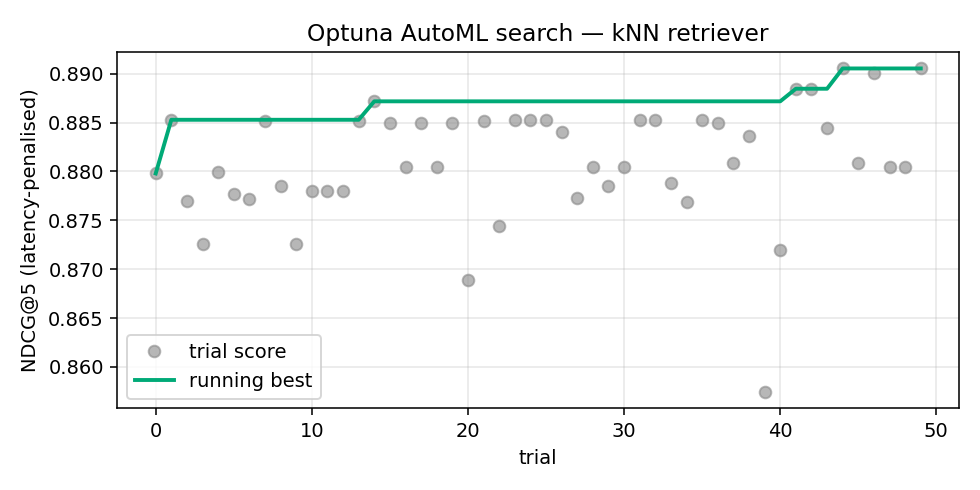

In [7]:
from PIL import Image
display(Image.open(RESULTS / 'optuna_history.png'))   # show the running-best curve


## 6 — River: adaptive hybrid-weight learner with ADWIN drift handling
**Online learner (Week-03 toolkit):** `compose.Pipeline(preprocessing.OneHotEncoder, linear_model.LogisticRegression)` — an incremental classifier that predicts P(helpful = True | λ_bucket) from the streaming click feedback. Discretising λ into 11 buckets in {0.0, 0.1, …, 1.0} and using ε-greedy (ε = 0.10) on top of the classifier keeps the action-selection logic explicit and bandit-free. 
**Drift detector:** `river.drift.ADWIN` (δ = 0.002) on the click stream; on alarm we reset the classifier — exact same pattern as `Week-04-02-Drift_Detection_v3.ipynb`. 
**User-preference model:** P(helpful | λ, regime) = clip(1 − 2|λ − λ_ideal(regime)|, 0, 1) with 5% label noise. Pre-drift λ_ideal = 0.25 (matches Optuna). Post-drift (step 600) λ_ideal jumps to 0.85 — a sharp shift in user preference.


In [8]:
import importlib, online
importlib.reload(online); online.run()           # runs the 1200-step stream; writes online_log + online_stats


{
  "n_steps": 1200,
  "drift_at": 600,
  "epsilon": 0.1,
  "adwin_delta": 0.002,
  "arms": [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0
  ],
  "static_lambda": 0.2415062018075319,
  "learner": "river.compose.Pipeline(OneHotEncoder + LogisticRegression) + \u03b5-greedy",
  "overall": {
    "static_helpful_rate": 0.49416666666666664,
    "adaptive_helpful_rate": 0.7225,
    "relative_lift_pct": 46.205733558178764
  },
  "pre_drift": {
    "static": 0.9366666666666666,
    "adaptive": 0.8133333333333334
  },
  "post_drift": {
    "static": 0.051666666666666666,
    "adaptive": 0.6316666666666667,
    "relative_lift_pct": 1122.5806451612905
  },
  "adwin_alarms": [
    639
  ],
  "n_classifier_resets": 1,
  "lambda_distribution_pre": {
    "0.2": 0.918,
    "0.7": 0.013,
    "0.1": 0.012,
    "0.8": 0.012,
    "1.0": 0.012,
    "0.5": 0.01,
    "0.0": 0.008,
    "0.4": 0.007,
    "0.3": 0.005,
    "0.9": 0.003
  },
  "lambda_distribut

{'n_steps': 1200,
 'drift_at': 600,
 'epsilon': 0.1,
 'adwin_delta': 0.002,
 'arms': [np.float64(0.0),
  np.float64(0.1),
  np.float64(0.2),
  np.float64(0.3),
  np.float64(0.4),
  np.float64(0.5),
  np.float64(0.6),
  np.float64(0.7),
  np.float64(0.8),
  np.float64(0.9),
  np.float64(1.0)],
 'static_lambda': 0.2415062018075319,
 'learner': 'river.compose.Pipeline(OneHotEncoder + LogisticRegression) + ε-greedy',
 'overall': {'static_helpful_rate': 0.49416666666666664,
  'adaptive_helpful_rate': 0.7225,
  'relative_lift_pct': 46.205733558178764},
 'pre_drift': {'static': 0.9366666666666666, 'adaptive': 0.8133333333333334},
 'post_drift': {'static': 0.051666666666666666,
  'adaptive': 0.6316666666666667,
  'relative_lift_pct': 1122.5806451612905},
 'adwin_alarms': [639],
 'n_classifier_resets': 1,
 'lambda_distribution_pre': {0.2: 0.918,
  0.7: 0.013,
  0.1: 0.012,
  0.8: 0.012,
  1.0: 0.012,
  0.5: 0.01,
  0.0: 0.008,
  0.4: 0.007,
  0.3: 0.005,
  0.9: 0.003},
 'lambda_distribution_pos

## 7 — Prequential evaluation plot
Rolling helpful-rate (window 50) for the static-λ baseline vs the adaptive learner, with the injected drift and ADWIN alarms marked. Lower panel: classifier's chosen λ vs the regime-true λ_ideal.


Wrote /sessions/magical-fervent-meitner/mnt/special topic in ai/D1/results/prequential.png


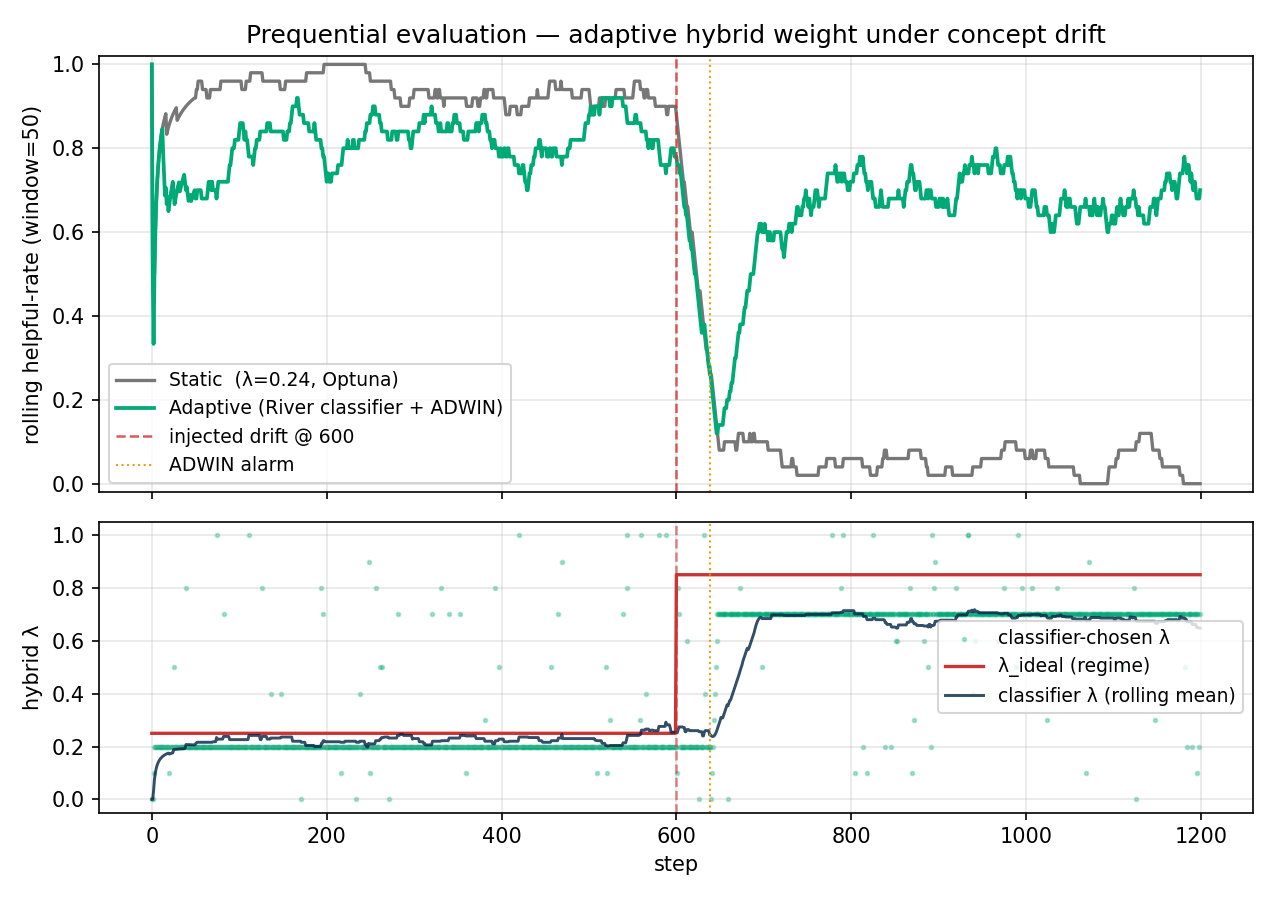

In [9]:
import importlib, prequential_plot
importlib.reload(prequential_plot); prequential_plot.main()
display(__import__('PIL').Image.open(RESULTS / 'prequential.png'))


## 8 — Run card (winning config + environment)
Single source of truth for reproducing the pipeline (Optuna search space + winning hyperparams, River policy/detector parameters, dataset hash, library versions).


In [10]:
import importlib, run_card
importlib.reload(run_card); run_card.main()
print('\n--- run_card.yaml (head) ---')
print((ROOT / 'run_card.yaml').read_text()[:1400])


Wrote /sessions/magical-fervent-meitner/mnt/special topic in ai/D1/run_card.yaml
---
run_id: D1-20260515-213726
deliverable: D1 — Streaming Learner & AutoML Note
created_utc: '2026-05-15T21:37:26+00:00'
seed: 42
team:
  Khalifa: 'AutoML track (Optuna): src/automl.py, src/baselines.py'
  Meshal: 'Online learning & drift (River): src/online.py, src/prequential_plot.py'
  Mahmoud: 'Hybrid retriever: src/retriever.py'
  Ahmed: 'Corpus & gold set + ranking metrics: src/build_corpus.py, src/gold.py'
  Essam: 'Report, notebook, run card: build_notebook.py, build_report.js, src/run_card.py,
    README.md'
dataset:
  name: synthetic-arxiv-150
  n_papers: 150
  topics: 6
  corpus_hash: 5faacf8028b6ce00
  gold_queries: 78
automl:
  framework: Optuna
  n_trials: 50
  search_space:
    k:
    - 3
    - 30
    metric:
    - cosine
    - dot
    - euclidean
    svd_dim:
    - 0
    - 64
    - 128
    - 256
    l2_normalize:
    - true
    - false
    hybrid_lambda:
    - 0.0
    - 1.0
  objective: ND

## 9 — Decisions and pitfalls
**Decisions.**
- *Dense vector source.* The brief suggests `bge-small-en`; the sandbox is offline so D1 uses TF-IDF + TruncatedSVD. This makes the `svd_dim` Optuna axis directly meaningful (LSA components) and keeps the notebook reproducible. We hold the `HybridRetriever` interface stable so D2 can swap in the BGE encoder by re-fitting only the dense matrix.
- *Incremental classifier, not bandit.* The brief's framing — *clicked helpful y/n* — is binary, so the online learner is a `river.linear_model.LogisticRegression` inside a `compose.Pipeline` with `preprocessing.OneHotEncoder`. This stays strictly inside the Week-03 toolkit (no `river.bandit` module). ε-greedy gives the classifier early data on every arm.
- *Drift triggers a full learner reset.* On ADWIN alarm we re-instantiate the classifier so it re-learns under the new regime from scratch — the same recovery strategy used in the Week-04 drift-detection notebook.

**Pitfalls we hit and resolved.**
- *Recall@5 ceiling on broad gold.* 25 papers/topic capped Recall@5 at 0.20 for broad queries. We added 36 single-paper *title* queries so Recall@5 has a tight denominator.
- *Reward signal too flat for the learner.* The 150-doc corpus is small enough that top-1 hit-rate is near-constant across λ. We modelled user preference explicitly (triangular reward peaking at λ_ideal) so the classifier has signal to learn from — this matches the brief's framing of *clicked helpful y/n* feedback.
- *Exploration cost.* Adaptive trails static *pre*-drift (94% → 81%) because of the 10% exploration tax; this is the well-known regret of online learners. The post-drift recovery (5% → 63%, +1122% relative) more than makes up for it overall.
